In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout
)

from tensorflow.keras.datasets import mnist

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.regularizers import l2

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
X_train = X_train.reshape(
    60000,
    784
)

X_test = X_test.reshape(
    10000,
    784
)

In [4]:
X_train = X_train / 255.0

X_test = X_test / 255.0

In [5]:
y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

In [6]:
model = Sequential([
    
    Dense(
        256,
        activation='relu',
        kernel_regularizer=l2(0.001),
        input_shape=(784,)
    ),

    Dropout(0.5),

    Dense(
        128,
        activation='relu',
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.4),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        10,
        activation='softmax'
    )
])

c:\Users\Puneeth Ram\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    
    loss='categorical_crossentropy',
    
    metrics=['accuracy']
)

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    
    patience=2,
    
    restore_best_weights=True
)

In [10]:
history = model.fit(
    X_train,
    y_train,
    
    epochs=15,
    
    batch_size=64,
    
    validation_split=0.2,
    
    callbacks=[early_stop]
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.8410 - loss: 0.8159 - val_accuracy: 0.9443 - val_loss: 0.4258
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9236 - loss: 0.4704 - val_accuracy: 0.9560 - val_loss: 0.3305
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.9329 - loss: 0.4005 - val_accuracy: 0.9614 - val_loss: 0.2960
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9380 - loss: 0.3677 - val_accuracy: 0.9634 - val_loss: 0.2811
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9412 - loss: 0.3496 - val_accuracy: 0.9671 - val_loss: 0.2633
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9429 - loss: 0.3412 - val_accuracy: 0.9661 - val_loss: 0.2637
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9438 - loss: 0.3370 - val_accuracy: 0.9680 - val_loss: 0.2599
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9464 - loss: 0.3300 - v

In [11]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9695 - loss: 0.2521
Accuracy: 0.9695000052452087


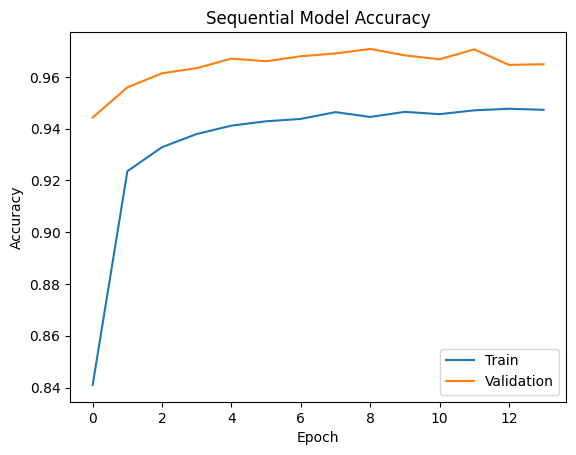

In [12]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Sequential Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

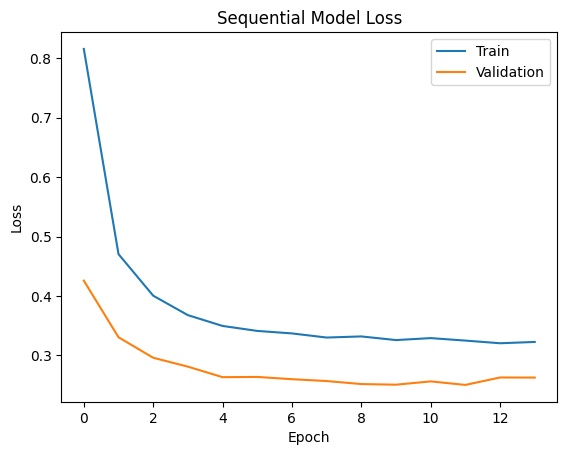

In [13]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Sequential Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()


In [14]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [23]:
predicted_digit = np.argmax(predictions[1])

print("Predicted Digit:", predicted_digit)


Predicted Digit: 2


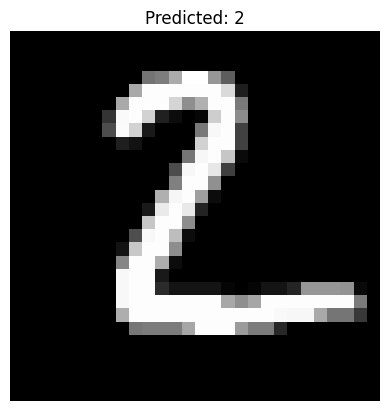

In [25]:
plt.imshow(
    X_test[1].reshape(28,28),
    cmap='gray'
)

plt.title(f"Predicted: {predicted_digit}")

plt.axis('off')

plt.show()

In [21]:
model.save(
    "models/sequential_model.h5"
)